In [23]:
# ============================================================
# IMPORT DES BIBLIOTHEQUES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
import hashlib
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Configuration des styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("[OK] Toutes les bibliotheques sont chargees")

[OK] Toutes les bibliotheques sont chargees


In [24]:
# ============================================================
# CONFIGURATION DES CHEMINS (VOTRE STRUCTURE WINDOWS)
# ============================================================

# Dossier racine
BASE_DIR = r"C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier"

# Sous-dossiers
MODELS_DIR = os.path.join(BASE_DIR, "modeles")
VIZ_DIR = os.path.join(BASE_DIR, "visualisations")
REPORTS_DIR = os.path.join(BASE_DIR, "rapports")
DATA_DIR = os.path.join(BASE_DIR, "data")

# Sous-dossiers data
DATA_RAW = os.path.join(DATA_DIR, "raw")
DATA_PROCESSED = os.path.join(DATA_DIR, "processed")
DATA_TRAIN = os.path.join(DATA_DIR, "train")
DATA_VAL = os.path.join(DATA_DIR, "val")
DATA_TEST = os.path.join(DATA_DIR, "test")

# Verification des dossiers
print("[OK] Configuration des chemins:")
print("  BASE_DIR: {}".format(BASE_DIR))
print("  MODELS_DIR: {}".format(MODELS_DIR))
print("  VIZ_DIR: {}".format(VIZ_DIR))
print("  REPORTS_DIR: {}".format(REPORTS_DIR))
print("  DATA_RAW: {}".format(DATA_RAW))
print("  DATA_PROCESSED: {}".format(DATA_PROCESSED))
print("  DATA_TRAIN: {}".format(DATA_TRAIN))
print("  DATA_VAL: {}".format(DATA_VAL))
print("  DATA_TEST: {}".format(DATA_TEST))

# Verification que les dossiers existent
for d in [BASE_DIR, MODELS_DIR, VIZ_DIR, REPORTS_DIR, DATA_DIR, 
          DATA_RAW, DATA_PROCESSED, DATA_TRAIN, DATA_VAL, DATA_TEST]:
    if os.path.exists(d):
        print("  [OK] {}".format(d))
    else:
        print("  [ERREUR] Dossier manquant: {}".format(d))

[OK] Configuration des chemins:
  BASE_DIR: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier
  MODELS_DIR: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\modeles
  VIZ_DIR: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\visualisations
  REPORTS_DIR: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\rapports
  DATA_RAW: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\data\raw
  DATA_PROCESSED: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\data\processed
  DATA_TRAIN: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\data\train
  DATA_VAL: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\data\val
  DATA_TEST: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\data\test
  [OK] C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\m

In [25]:
# ============================================================
# CHARGEMENT DU DATASET
# ============================================================

print("\n" + "="*60)
print("CHARGEMENT DU DATASET")
print("="*60)

# Chemins complets des fichiers
RAW_FILE = os.path.join(DATA_RAW, "dataset_minier_complet_50000.csv")
PROCESSED_FILE = os.path.join(DATA_PROCESSED, "dataset_minier_processed.csv")
TRAIN_FILE = os.path.join(DATA_TRAIN, "train.csv")
VAL_FILE = os.path.join(DATA_VAL, "val.csv")
TEST_FILE = os.path.join(DATA_TEST, "test.csv")

try:
    raw_df = pd.read_csv(RAW_FILE)
    df = pd.read_csv(PROCESSED_FILE)
    train_df = pd.read_csv(TRAIN_FILE)
    val_df = pd.read_csv(VAL_FILE)
    test_df = pd.read_csv(TEST_FILE)
    print("[OK] Dataset charge depuis:")
    print("  - {}".format(RAW_FILE))
    print("  - {}".format(PROCESSED_FILE))
    print("  - {}".format(TRAIN_FILE))
    print("  - {}".format(VAL_FILE))
    print("  - {}".format(TEST_FILE))
    
except FileNotFoundError as e:
    print("[ERREUR] Fichier non trouve: {}".format(e))
    print("\nVerifiez que les fichiers existent:")
    print("  - {}".format(RAW_FILE))
    print("  - {}".format(PROCESSED_FILE))
    print("  - {}".format(TRAIN_FILE))
    print("  - {}".format(VAL_FILE))
    print("  - {}".format(TEST_FILE))
    raise

print("\nInformations du dataset brut: {}".format(raw_df.shape))
print("Informations du dataset traite: {}".format(df.shape))
print("Train: {}".format(train_df.shape))
print("Validation: {}".format(val_df.shape))
print("Test: {}".format(test_df.shape))
print("\nColonnes disponibles: {}".format(list(df.columns)))


CHARGEMENT DU DATASET
[OK] Dataset charge depuis:
  - C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\data\raw\dataset_minier_complet_50000.csv
  - C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\data\processed\dataset_minier_processed.csv
  - C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\data\train\train.csv
  - C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\data\val\val.csv
  - C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\data\test\test.csv

Informations du dataset brut: (50000, 37)
Informations du dataset traite: (50000, 37)
Train: (35000, 37)
Validation: (7500, 37)
Test: (7500, 37)

Colonnes disponibles: ['lot_id', 'site', 'cu_grade_percent', 'co_grade_percent', 'fe_percent', 'ni_percent', 'mn_percent', 's_percent', 'moisture_percent', 'density_t_m3', 'weight_tonnes', 'mineral_class', 'impurity_level', 'gps_lat', 'gps_lon', 'precise


ANALYSE EXPLORATOIRE

Statistiques des principales variables:
       cu_grade_percent  co_grade_percent    fe_percent  density_t_m3  \
count      50000.000000      50000.000000  50000.000000  50000.000000   
mean           3.536802          2.776293      1.501510      3.001283   
std            1.270493          1.017073      0.685461      0.872654   
min           -1.800000         -1.680000      0.000000      1.010000   
25%            2.700000          2.090000      1.030000      2.240000   
50%            3.520000          2.780000      1.500000      3.000000   
75%            4.330000          3.460000      1.970000      3.760000   
max           16.520000          7.420000      4.450000      4.990000   

       weight_tonnes  
count   50000.000000  
mean       55.177171  
std        26.286310  
min         5.050000  
25%        32.530000  
50%        55.200000  
75%        77.610000  
max       149.740000  


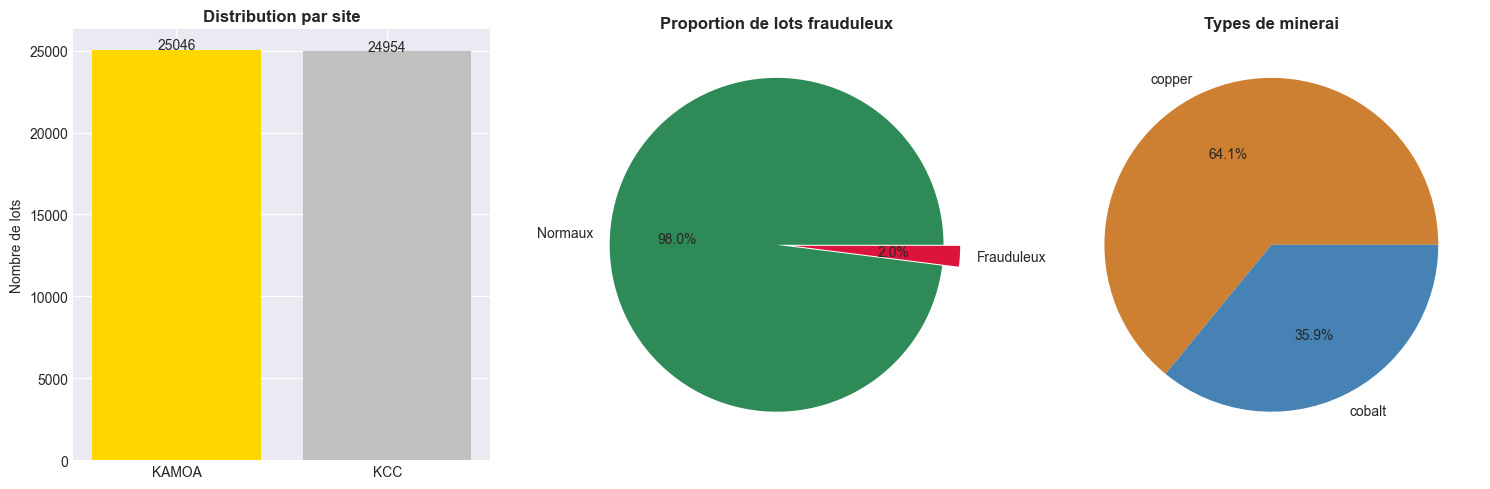

[OK] Graphique sauvegarde: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\visualisations\1_distribution_generale.png


In [26]:
# ============================================================
# ANALYSE EXPLORATOIRE
# ============================================================

print("\n" + "="*60)
print("ANALYSE EXPLORATOIRE")
print("="*60)

# Statistiques descriptives
print("\nStatistiques des principales variables:")
print(df[['cu_grade_percent', 'co_grade_percent', 'fe_percent',
          'density_t_m3', 'weight_tonnes']].describe())

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribution par site
if 'site' in df.columns:
    site_counts = df['site'].value_counts()
    axes[0].bar(site_counts.index, site_counts.values, color=['#FFD700', '#C0C0C0'])
    axes[0].set_title('Distribution par site', fontweight='bold')
    axes[0].set_ylabel('Nombre de lots')
    for i, v in enumerate(site_counts.values):
        axes[0].text(i, v + 50, str(v), ha='center')

# Proportion de lots frauduleux
if 'fraud_flag' in df.columns:
    fraud_counts = df['fraud_flag'].value_counts()
    axes[1].pie(fraud_counts.values, labels=['Normaux', 'Frauduleux'],
                autopct='%1.1f%%', colors=['#2E8B57', '#DC143C'], explode=(0, 0.1))
    axes[1].set_title('Proportion de lots frauduleux', fontweight='bold')

# Types de minerai
if 'mineral_class' in df.columns:
    mineral_counts = df['mineral_class'].value_counts()
    axes[2].pie(mineral_counts.values, labels=mineral_counts.index,
                autopct='%1.1f%%', colors=['#CD7F32', '#4682B4'])
    axes[2].set_title('Types de minerai', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '1_distribution_generale.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("[OK] Graphique sauvegarde: {}".format(os.path.join(VIZ_DIR, '1_distribution_generale.png')))

In [27]:
# ============================================================
# PREPARATION DES DONNEES + FEATURES METIER
# ============================================================

print("\n" + "="*60)
print("PREPARATION DES DONNEES + FEATURES METIER")
print("="*60)

def add_business_features(data):
    data = data.copy()
    eps = 1e-6

    # Ratios et indicateurs geochimiques utiles pour separer cuivre/cobalt/fraude
    data["cu_co_ratio"] = data["cu_grade_percent"] / (data["co_grade_percent"] + eps)
    data["co_cu_ratio"] = data["co_grade_percent"] / (data["cu_grade_percent"] + eps)
    data["impurity_sum"] = data[["fe_percent", "ni_percent", "mn_percent", "s_percent", "silica_percent", "alumina_percent", "magnesia_percent"]].sum(axis=1)
    data["base_metal_sum"] = data["cu_grade_percent"] + data["co_grade_percent"]
    data["quality_score"] = data["base_metal_sum"] - data["impurity_sum"]
    data["grade_density_ratio"] = data["base_metal_sum"] / (data["density_t_m3"] + eps)
    data["grade_weight_ratio"] = data["base_metal_sum"] / (data["weight_tonnes"] + eps)
    data["moisture_density_ratio"] = data["moisture_percent"] / (data["density_t_m3"] + eps)

    if "grade_deviation" in data.columns:
        data["grade_deviation_abs"] = data["grade_deviation"].abs()

    return data

# Application identique sur train/validation/test pour eviter la fuite de donnees
train_fe = add_business_features(train_df)
val_fe = add_business_features(val_df)
test_fe = add_business_features(test_df)
df_fe = add_business_features(df)

feature_columns = [
    "cu_grade_percent", "co_grade_percent", "fe_percent", "ni_percent", "mn_percent", "s_percent",
    "silica_percent", "alumina_percent", "magnesia_percent", "density_t_m3", "moisture_percent",
    "hardness_mohs", "ph", "granulometry_mm", "weight_tonnes", "electrical_conductivity",
    "grade_deviation", "grade_deviation_abs", "cu_co_ratio", "co_cu_ratio", "impurity_sum",
    "base_metal_sum", "quality_score", "grade_density_ratio", "grade_weight_ratio",
    "moisture_density_ratio"
]

available_features = [f for f in feature_columns if f in train_fe.columns]
print("Features disponibles: {}/{}".format(len(available_features), len(feature_columns)))
for i, f in enumerate(available_features):
    print("  {}. {}".format(i+1, f))

def prepare_X(data):
    X = data[available_features].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    return X

X_train_raw = prepare_X(train_fe)
X_val_raw = prepare_X(val_fe)
X_test_raw = prepare_X(test_fe)
X_full_raw = prepare_X(df_fe)

# Remplissage avec les moyennes du train uniquement
train_means = X_train_raw.mean()
X_train_raw = X_train_raw.fillna(train_means)
X_val_raw = X_val_raw.fillna(train_means)
X_test_raw = X_test_raw.fillna(train_means)
X_full_raw = X_full_raw.fillna(train_means)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)
X_scaled = scaler.transform(X_full_raw)

print("\nShapes:")
print("  Train: {}".format(X_train_scaled.shape))
print("  Validation: {}".format(X_val_scaled.shape))
print("  Test: {}".format(X_test_scaled.shape))
print("[OK] Standardisation terminee sans fuite de donnees")

# Preparation des cibles
if 'mineral_class' in train_fe.columns:
    le_mineral = LabelEncoder()
    y_train_mineral = le_mineral.fit_transform(train_fe['mineral_class'])
    y_val_mineral = le_mineral.transform(val_fe['mineral_class'])
    y_test_mineral = le_mineral.transform(test_fe['mineral_class'])
    y_mineral = le_mineral.transform(df_fe['mineral_class'])
    print("[OK] Encodage mineral_class: {}".format(list(le_mineral.classes_)))

if 'impurity_level' in train_fe.columns:
    le_impurity = LabelEncoder()
    y_train_impurity = le_impurity.fit_transform(train_fe['impurity_level'])
    y_val_impurity = le_impurity.transform(val_fe['impurity_level'])
    y_test_impurity = le_impurity.transform(test_fe['impurity_level'])
    y_impurity = le_impurity.transform(df_fe['impurity_level'])
    print("[OK] Encodage impurity_level: {}".format(list(le_impurity.classes_)))

if 'fraud_flag' in train_fe.columns:
    y_train_fraud = train_fe['fraud_flag'].astype(int).values
    y_val_fraud = val_fe['fraud_flag'].astype(int).values
    y_test_fraud = test_fe['fraud_flag'].astype(int).values
    y_fraud = df_fe['fraud_flag'].astype(int).values
    print("[OK] Fraudes train/val/test: {} / {} / {}".format(y_train_fraud.sum(), y_val_fraud.sum(), y_test_fraud.sum()))


PREPARATION DES DONNEES + FEATURES METIER
Features disponibles: 26/26
  1. cu_grade_percent
  2. co_grade_percent
  3. fe_percent
  4. ni_percent
  5. mn_percent
  6. s_percent
  7. silica_percent
  8. alumina_percent
  9. magnesia_percent
  10. density_t_m3
  11. moisture_percent
  12. hardness_mohs
  13. ph
  14. granulometry_mm
  15. weight_tonnes
  16. electrical_conductivity
  17. grade_deviation
  18. grade_deviation_abs
  19. cu_co_ratio
  20. co_cu_ratio
  21. impurity_sum
  22. base_metal_sum
  23. quality_score
  24. grade_density_ratio
  25. grade_weight_ratio
  26. moisture_density_ratio

Shapes:
  Train: (35000, 26)
  Validation: (7500, 26)
  Test: (7500, 26)
[OK] Standardisation terminee sans fuite de donnees
[OK] Encodage mineral_class: ['cobalt', 'copper']
[OK] Encodage impurity_level: ['high', 'low', 'medium']
[OK] Fraudes train/val/test: 692 / 141 / 164



MODELE 1: IDENTIFICATION DU TYPE DE MINERAI
Classes: ['cobalt', 'copper']

Distribution APRES SMOTE:
  Train - cobalt: 22381
  Train - copper: 22381

Entrainement en cours...

RESULTATS TEST:
  Accuracy: 0.7976 (79.76%)
  F1-Score pondere: 0.8000

Rapport de classification:
              precision    recall  f1-score   support

      cobalt       0.69      0.78      0.73      2676
      copper       0.87      0.81      0.84      4824

    accuracy                           0.80      7500
   macro avg       0.78      0.79      0.79      7500
weighted avg       0.81      0.80      0.80      7500



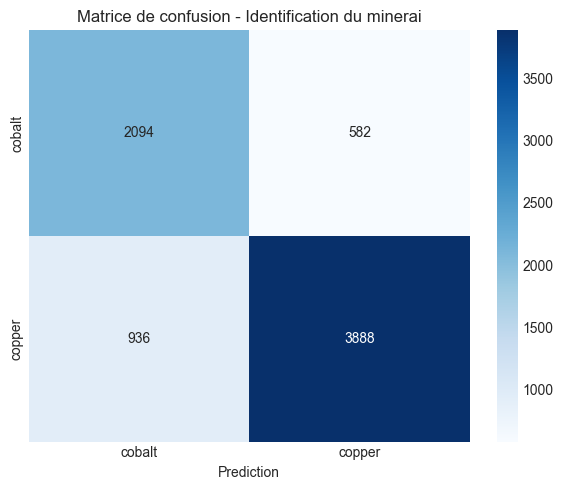


[OK] Modele 1 entraine avec succes


In [33]:
# ============================================================
# MODELE 1: IDENTIFICATION DU TYPE DE MINERAI
# ============================================================

print("\n" + "="*60)
print("MODELE 1: IDENTIFICATION DU TYPE DE MINERAI")
print("="*60)

if 'mineral_class' in train_fe.columns:
    print("Classes: {}".format(list(le_mineral.classes_)))

    smote_mineral = SMOTE(random_state=42)
    X_train_mineral_res, y_train_mineral_res = smote_mineral.fit_resample(X_train_scaled, y_train_mineral)

    print("\nDistribution APRES SMOTE:")
    unique, counts = np.unique(y_train_mineral_res, return_counts=True)
    for u, c in zip(unique, counts):
        print("  Train - {}: {}".format(le_mineral.classes_[u], c))

    model_mineral = RandomForestClassifier(
        n_estimators=300, max_depth=18, min_samples_leaf=2,
        random_state=42, class_weight="balanced", n_jobs=-1
    )

    print("\nEntrainement en cours...")
    model_mineral.fit(X_train_mineral_res, y_train_mineral_res)

    y_pred_m = model_mineral.predict(X_test_scaled)
    acc_m = accuracy_score(y_test_mineral, y_pred_m)
    f1_m = f1_score(y_test_mineral, y_pred_m, average="weighted")

    print("\nRESULTATS TEST:")
    print("  Accuracy: {:.4f} ({:.2f}%)".format(acc_m, acc_m*100))
    print("  F1-Score pondere: {:.4f}".format(f1_m))
    print("\nRapport de classification:")
    print(classification_report(y_test_mineral, y_pred_m, target_names=le_mineral.classes_))

    cm = confusion_matrix(y_test_mineral, y_pred_m)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_mineral.classes_, yticklabels=le_mineral.classes_)
    plt.title('Matrice de confusion - Identification du minerai')
    plt.xlabel('Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, 'confusion_identification.png'), dpi=300)
    plt.show()

    print("\n[OK] Modele 1 entraine avec succes")
else:
    print("[ERREUR] Colonne 'mineral_class' non trouvee")


MODELE 2: CLASSIFICATION DU NIVEAU D'IMPURETE
Classes: ['high', 'low', 'medium']

Distribution APRES SMOTE:
  Train - high: 25007
  Train - low: 25007
  Train - medium: 25007

Entrainement en cours...

RESULTATS TEST:
  Accuracy: 0.9248 (92.48%)
  F1-Score pondere: 0.9260

Rapport de classification:
              precision    recall  f1-score   support

        high       0.86      0.92      0.89      1474
         low       0.79      0.90      0.84       708
      medium       0.97      0.93      0.95      5318

    accuracy                           0.92      7500
   macro avg       0.87      0.92      0.89      7500
weighted avg       0.93      0.92      0.93      7500



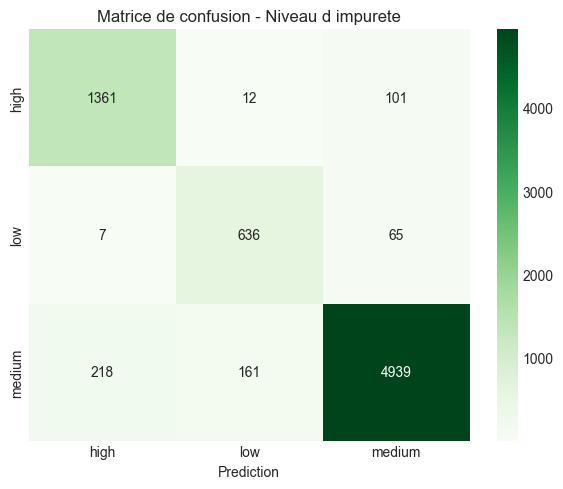


[OK] Modele 2 entraine avec succes


In [34]:
# ============================================================
# MODELE 2: CLASSIFICATION DU NIVEAU D'IMPURETE
# ============================================================

print("\n" + "="*60)
print("MODELE 2: CLASSIFICATION DU NIVEAU D'IMPURETE")
print("="*60)

if 'impurity_level' in train_fe.columns:
    print("Classes: {}".format(list(le_impurity.classes_)))

    smote_impurity = SMOTE(random_state=42)
    X_train_impurity_res, y_train_impurity_res = smote_impurity.fit_resample(X_train_scaled, y_train_impurity)

    print("\nDistribution APRES SMOTE:")
    unique, counts = np.unique(y_train_impurity_res, return_counts=True)
    for u, c in zip(unique, counts):
        print("  Train - {}: {}".format(le_impurity.classes_[u], c))

    model_impurity = RandomForestClassifier(
        n_estimators=300, max_depth=16, min_samples_leaf=2,
        random_state=42, class_weight="balanced", n_jobs=-1
    )

    print("\nEntrainement en cours...")
    model_impurity.fit(X_train_impurity_res, y_train_impurity_res)

    y_pred_i = model_impurity.predict(X_test_scaled)
    acc_i = accuracy_score(y_test_impurity, y_pred_i)
    f1_i = f1_score(y_test_impurity, y_pred_i, average="weighted")

    print("\nRESULTATS TEST:")
    print("  Accuracy: {:.4f} ({:.2f}%)".format(acc_i, acc_i*100))
    print("  F1-Score pondere: {:.4f}".format(f1_i))
    print("\nRapport de classification:")
    print(classification_report(y_test_impurity, y_pred_i, target_names=le_impurity.classes_))

    cm = confusion_matrix(y_test_impurity, y_pred_i)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=le_impurity.classes_, yticklabels=le_impurity.classes_)
    plt.title('Matrice de confusion - Niveau d impurete')
    plt.xlabel('Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, 'confusion_impurity.png'), dpi=300)
    plt.show()

    print("\n[OK] Modele 2 entraine avec succes")
else:
    print("[ERREUR] Colonne 'impurity_level' non trouvee")


MODELE 3: DETECTION DE FRAUDE AMELIOREE

Distribution initiale:
  Train - Normal: 34308 | Fraude: 692 (1.98%)
  Val   - Normal: 7359 | Fraude: 141 (1.88%)
  Test  - Normal: 7336 | Fraude: 164 (2.19%)

Distribution APRES SMOTE PARTIEL (TRAIN):
  Normal (0): 34308
  Fraude (1): 12007

Entrainement en cours...

OPTIMISATION DU SEUIL SUR VALIDATION:
Seuil | Precision fraude | Rappel fraude | F1 fraude
----------------------------------------------------------
0.05   |      0.0187      |    0.9858    |  0.0368
0.10   |      0.0188      |    0.9362    |  0.0370
0.15   |      0.0196      |    0.9078    |  0.0384
0.20   |      0.0199      |    0.8794    |  0.0390
0.25   |      0.0203      |    0.8511    |  0.0397
0.30   |      0.0199      |    0.7801    |  0.0388
0.35   |      0.0204      |    0.7376    |  0.0396
0.40   |      0.0208      |    0.6950    |  0.0403
0.45   |      0.0203      |    0.6170    |  0.0393
0.50   |      0.0208      |    0.5674    |  0.0400
0.55   |      0.0207      |  

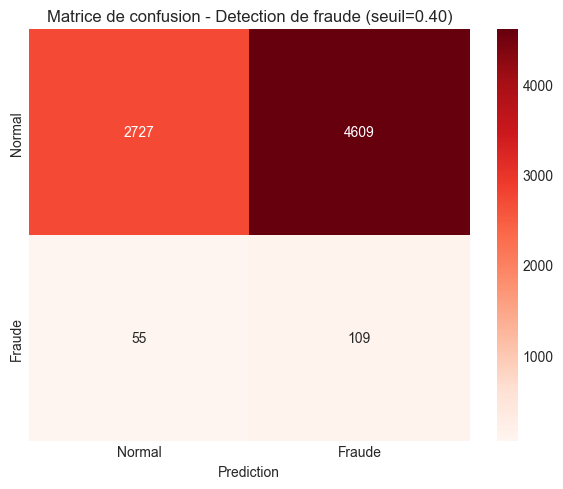


[OK] Modele 3 entraine avec succes


In [35]:
# ============================================================
# MODELE 3: DETECTION DE FRAUDE AMELIOREE
# ============================================================

print("\n" + "="*60)
print("MODELE 3: DETECTION DE FRAUDE AMELIOREE")
print("="*60)

if 'fraud_flag' in train_fe.columns:
    print("\nDistribution initiale:")
    print("  Train - Normal: {} | Fraude: {} ({:.2f}%)".format((y_train_fraud == 0).sum(), y_train_fraud.sum(), y_train_fraud.mean()*100))
    print("  Val   - Normal: {} | Fraude: {} ({:.2f}%)".format((y_val_fraud == 0).sum(), y_val_fraud.sum(), y_val_fraud.mean()*100))
    print("  Test  - Normal: {} | Fraude: {} ({:.2f}%)".format((y_test_fraud == 0).sum(), y_test_fraud.sum(), y_test_fraud.mean()*100))

    # SMOTE partiel: on augmente les fraudes sans rendre le train artificiellement 50/50.
    smote_fraud = SMOTE(random_state=42, sampling_strategy=0.35, k_neighbors=5)
    X_train_fraud_res, y_train_fraud_res = smote_fraud.fit_resample(X_train_scaled, y_train_fraud)

    print("\nDistribution APRES SMOTE PARTIEL (TRAIN):")
    print("  Normal (0): {}".format((y_train_fraud_res == 0).sum()))
    print("  Fraude (1): {}".format((y_train_fraud_res == 1).sum()))

    model_fraud = RandomForestClassifier(
        n_estimators=500, max_depth=14, min_samples_leaf=2,
        class_weight={0: 1, 1: 8}, random_state=42, n_jobs=-1
    )

    print("\nEntrainement en cours...")
    model_fraud.fit(X_train_fraud_res, y_train_fraud_res)

    # Le seuil est choisi sur validation, puis evalue une seule fois sur test.
    y_val_proba_f = model_fraud.predict_proba(X_val_scaled)[:, 1]
    thresholds = np.arange(0.05, 0.76, 0.05)
    best_threshold = 0.50
    best_f1_fraud_val = -1

    print("\nOPTIMISATION DU SEUIL SUR VALIDATION:")
    print("Seuil | Precision fraude | Rappel fraude | F1 fraude")
    print("-" * 58)
    for thresh in thresholds:
        y_val_pred = (y_val_proba_f >= thresh).astype(int)
        prec = precision_score(y_val_fraud, y_val_pred, pos_label=1, zero_division=0)
        rec = recall_score(y_val_fraud, y_val_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_val_fraud, y_val_pred, pos_label=1, zero_division=0)
        print("{:.2f}   |      {:.4f}      |    {:.4f}    |  {:.4f}".format(thresh, prec, rec, f1))
        if f1 > best_f1_fraud_val:
            best_f1_fraud_val = f1
            best_threshold = float(thresh)

    print("-" * 58)
    print("Meilleur seuil validation: {:.2f} (F1 fraude val = {:.4f})".format(best_threshold, best_f1_fraud_val))

    y_proba_f = model_fraud.predict_proba(X_test_scaled)[:, 1]
    y_pred_f = (y_proba_f >= best_threshold).astype(int)

    acc_f = accuracy_score(y_test_fraud, y_pred_f)
    f1_f = f1_score(y_test_fraud, y_pred_f, average="weighted")
    prec_fraud = precision_score(y_test_fraud, y_pred_f, pos_label=1, zero_division=0)
    rec_fraud = recall_score(y_test_fraud, y_pred_f, pos_label=1, zero_division=0)
    f1_fraud = f1_score(y_test_fraud, y_pred_f, pos_label=1, zero_division=0)
    roc_auc_f = roc_auc_score(y_test_fraud, y_proba_f)
    pr_auc_f = average_precision_score(y_test_fraud, y_proba_f)

    print("\nRESULTATS TEST AVEC SEUIL OPTIMAL ({:.2f}):".format(best_threshold))
    print("  Accuracy: {:.4f} ({:.2f}%)".format(acc_f, acc_f*100))
    print("  F1-Score pondere: {:.4f}".format(f1_f))
    print("  Precision fraude: {:.4f}".format(prec_fraud))
    print("  Rappel fraude:    {:.4f}".format(rec_fraud))
    print("  F1 fraude:        {:.4f}".format(f1_fraud))
    print("  ROC-AUC:          {:.4f}".format(roc_auc_f))
    print("  PR-AUC:           {:.4f}".format(pr_auc_f))

    print("\nRapport de classification complet:")
    print(classification_report(y_test_fraud, y_pred_f, target_names=['Normal (0)', 'Fraude (1)'], zero_division=0))

    cm = confusion_matrix(y_test_fraud, y_pred_f)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'])
    plt.title('Matrice de confusion - Detection de fraude (seuil={:.2f})'.format(best_threshold))
    plt.xlabel('Prediction')
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, 'confusion_fraud.png'), dpi=300)
    plt.savefig(os.path.join(VIZ_DIR, '5_confusion_fraude_seuil_optimal.png'), dpi=300)
    plt.show()

    fraud_config = {
        "threshold": best_threshold,
        "validation_f1_fraud": best_f1_fraud_val,
        "test_accuracy": acc_f,
        "test_f1_weighted": f1_f,
        "test_precision_fraud": prec_fraud,
        "test_recall_fraud": rec_fraud,
        "test_f1_fraud": f1_fraud,
        "test_roc_auc": roc_auc_f,
        "test_pr_auc": pr_auc_f,
        "smote_sampling_strategy": 0.35,
        "class_weight": {"0": 1, "1": 8}
    }

    print("\n[OK] Modele 3 entraine avec succes")
else:
    print("[ERREUR] Colonne 'fraud_flag' non trouvee")

In [31]:
# ============================================================
# SAUVEGARDE DES MODELES
# ============================================================

print("\n" + "="*60)
print("SAUVEGARDE DES MODELES")
print("="*60)

if 'model_mineral' in locals():
    joblib.dump(model_mineral, os.path.join(MODELS_DIR, "model_mineral_type.pkl"))
    print("[OK] model_mineral_type.pkl sauvegarde")

if 'model_impurity' in locals():
    joblib.dump(model_impurity, os.path.join(MODELS_DIR, "model_impurity_level.pkl"))
    print("[OK] model_impurity_level.pkl sauvegarde")

if 'model_fraud' in locals():
    joblib.dump(model_fraud, os.path.join(MODELS_DIR, "model_fraud_detection.pkl"))
    print("[OK] model_fraud_detection.pkl sauvegarde")

if 'scaler' in locals():
    joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))
    print("[OK] scaler.pkl sauvegarde")

if 'train_means' in locals():
    joblib.dump(train_means, os.path.join(MODELS_DIR, "feature_means.pkl"))
    print("[OK] feature_means.pkl sauvegarde")

if 'available_features' in locals():
    joblib.dump(available_features, os.path.join(MODELS_DIR, "feature_columns.pkl"))
    print("[OK] feature_columns.pkl sauvegarde")

if 'fraud_config' in locals():
    with open(os.path.join(MODELS_DIR, "fraud_threshold_config.json"), "w", encoding="utf-8") as f:
        json.dump(fraud_config, f, indent=2)
    print("[OK] fraud_threshold_config.json sauvegarde")

if 'le_mineral' in locals():
    joblib.dump(le_mineral, os.path.join(MODELS_DIR, "label_encoder_mineral.pkl"))
    print("[OK] label_encoder_mineral.pkl sauvegarde")

if 'le_impurity' in locals():
    joblib.dump(le_impurity, os.path.join(MODELS_DIR, "label_encoder_impurity.pkl"))
    print("[OK] label_encoder_impurity.pkl sauvegarde")

print("\n[OK] Tous les modeles sauvegardes dans: {}".format(MODELS_DIR))


SAUVEGARDE DES MODELES
[OK] model_mineral_type.pkl sauvegarde
[OK] model_impurity_level.pkl sauvegarde
[OK] model_fraud_detection.pkl sauvegarde
[OK] scaler.pkl sauvegarde
[OK] feature_means.pkl sauvegarde
[OK] feature_columns.pkl sauvegarde
[OK] fraud_threshold_config.json sauvegarde
[OK] label_encoder_mineral.pkl sauvegarde
[OK] label_encoder_impurity.pkl sauvegarde

[OK] Tous les modeles sauvegardes dans: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\modeles


In [32]:
# ============================================================
# RAPPORT FINAL
# ============================================================

print("\n" + "="*60)
print("RAPPORT FINAL D'ENTRAINEMENT")
print("="*60)
print("")
print("DATASET")
print("  Total lots: {}".format(len(df)))
print("  Train / Val / Test: {} / {} / {}".format(len(train_df), len(val_df), len(test_df)))
print("  Features utilisees: {}".format(len(available_features)))
if 'mineral_class' in df.columns:
    print("  Types minerai: {}".format(', '.join(le_mineral.classes_)))
print("  Fraudes test: {} ({:.2f}%)".format(y_test_fraud.sum(), y_test_fraud.mean()*100))
print("")
print("PERFORMANCES SUR TEST")
if 'acc_m' in locals():
    print("  Identification minerai: Accuracy = {:.2f}%, F1 pondere = {:.2f}%".format(acc_m*100, f1_m*100))
if 'acc_i' in locals():
    print("  Niveau impurete:        Accuracy = {:.2f}%, F1 pondere = {:.2f}%".format(acc_i*100, f1_i*100))
if 'acc_f' in locals():
    print("  Detection fraude:       Accuracy = {:.2f}%, F1 pondere = {:.2f}%".format(acc_f*100, f1_f*100))
    print("  Fraude seule:           Precision = {:.2f}%, Rappel = {:.2f}%, F1 = {:.2f}%".format(prec_fraud*100, rec_fraud*100, f1_fraud*100))
    print("  Seuil fraude:           {:.2f}".format(best_threshold))
    print("  ROC-AUC / PR-AUC:       {:.2f}% / {:.2f}%".format(roc_auc_f*100, pr_auc_f*100))
print("")
print("FICHIERS SAUVEGARDES")
print("  Dossier: {}".format(BASE_DIR))
print("  Modeles: {}".format(MODELS_DIR))
print("  Visualisations: {}".format(VIZ_DIR))
print("")
print("="*60)
print("[OK] ENTRAINEMENT TERMINE AVEC SUCCES")
print("="*60)


RAPPORT FINAL D'ENTRAINEMENT

DATASET
  Total lots: 50000
  Train / Val / Test: 35000 / 7500 / 7500
  Features utilisees: 26
  Types minerai: cobalt, copper
  Fraudes test: 164 (2.19%)

PERFORMANCES SUR TEST
  Identification minerai: Accuracy = 79.76%, F1 pondere = 80.00%
  Niveau impurete:        Accuracy = 92.48%, F1 pondere = 92.60%
  Detection fraude:       Accuracy = 37.81%, F1 pondere = 52.82%
  Fraude seule:           Precision = 2.31%, Rappel = 66.46%, F1 = 4.47%
  Seuil fraude:           0.40
  ROC-AUC / PR-AUC:       51.54% / 2.30%

FICHIERS SAUVEGARDES
  Dossier: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier
  Modeles: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\modeles
  Visualisations: C:\Users\Dr_Denise\Desktop\Gracy\memoire\mineralchainProjet\modele_ia_minier\visualisations

[OK] ENTRAINEMENT TERMINE AVEC SUCCES
